# Bayesian Estimation of Hidden Rooftop Solar Generation in Spain

---

## Motivation

On **28 April 2025**, Spain experienced its largest nationwide blackout in recent history. One proposed factor for this outrage was the growing *invisible* generation from rooftop solar panels: when panels produce electricity that is consumed directly on-site, that energy never reaches the grid and is therefore invisible to system operators. The grid records lower apparent demand than the true consumption, because part of the load is covered without being detected.

This notebook builds a **Bayesian latent variable model** to estimate the size of this hidden contribution, using 11 years of daily national grid demand and weather data.

### The model equation

$$D_t = \underbrace{\mu_t}_{\text{weather baseline}} - \underbrace{\eta \cdot H_t}_{\text{hidden solar}} + \varepsilon_t$$

| Symbol | Meaning |
|--------|---------|
| $D_t$ | Observed daily grid demand (MWh): what REE records |
| $\mu_t$ | Baseline demand: what demand should be given weather, weekday, and season |
| $H_t = C_t \times S_t$ | Solar proxy: installed rooftop capacity × sunshine hours |
| $\eta$ | **The parameter we estimate**: fraction of theoretical solar that reduces grid-recorded demand |
| $\varepsilon_t$ | Observation noise |

### Why Bayesian?

$\eta$ is never directly observed. It only appears as a gap between baseline demand and recorded demand. Bayesian inference gives us a posterior distribution over $\eta$, propagating the uncertainty through to all derived quantities (annual hidden solar, April 28 estimates, etc.).


In [1]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

print(f"NumPy version: {np.__version__}")
print("PyMC imported successfully!")

NumPy version: 1.26.4
PyMC imported successfully!


In [3]:
import pytensor

# Disable C++ compilation to stop macOS warning spam.
pytensor.config.cxx = ""

import warnings

warnings.filterwarnings("ignore")

## 1. Data Loading and Feature Engineering

We load the merged dataset (4,138 daily observations, January 2015 to April 2026) and compute three sets of engineered features before any modelling:

**Fourier harmonics**: three sine/cosine pairs capture annual seasonality without requiring a parameter per month. Three harmonics (K=3) reproduce the main seasonal patterns (winter peak, summer cooling) with only 6 parameters.

**Solar proxy (`proxy_norm`)**: the key predictor for hidden solar. We use `selfcons_theoretical_mwh` (installed rooftop capacity × daily sunshine hours across 17 AEMET stations) divided by `demand_std`. Dividing by `demand_std` rather than z-scoring avoids negative values for pre-2020 years where capacity was near zero. Pre-2020 values are set to exactly 0 because the signal is not identifiable at that scale of installation.

**Monthly shock dummies**: 46 dummy variables, one per calendar month from March 2020 through December 2023. These absorb the COVID-19 lockdown demand destruction and the 2022 energy price crisis demand reduction. Without them, the model would inflate $\eta$ to explain those demand drops as if they were caused by solar generation.


In [4]:
# Load dataset
df = pd.read_csv("../data/merged/merged_dataset.csv")
df["date"] = pd.to_datetime(df["date"])

# Fourier harmonics for annual seasonality (K=3 pairs)
for k in range(1, 4):
    df[f"sin_k{k}"] = np.sin(2 * np.pi * k * df["day_of_year"] / 365.25)
    df[f"cos_k{k}"] = np.cos(2 * np.pi * k * df["day_of_year"] / 365.25)

# Standardisation constants (stored for back-calculation)
demand_mean, demand_std = df["demand_mwh_day"].mean(), df["demand_mwh_day"].std()

# Demand z-score and temperature z-score
df["demand_scaled"] = (df["demand_mwh_day"] - demand_mean) / demand_std
df["temp_scaled"] = (df["temp_mean_c"] - df["temp_mean_c"].mean()) / df[
    "temp_mean_c"
].std()

# Solar proxy: proxy_norm = selfcons / demand_std
df["proxy_norm"] = df["selfcons_theoretical_mwh"] / demand_std
df.loc[df["year"] < 2020, "proxy_norm"] = 0.0  # negligible pre-2020 capacity

# Monthly shock dummies (March 2020 to December 2023)
# 46 dummies absorb COVID lockdown and energy crisis demand destruction.
shock_start = pd.Timestamp("2020-03-01")
shock_end = pd.Timestamp("2023-12-31")
shock_months = pd.period_range(shock_start, shock_end, freq="M")
shock_cols = []
for period in shock_months:
    col = f"shock_{period.year}_{period.month:02d}"
    df[col] = (df["date"].dt.to_period("M") == period).astype(float)
    shock_cols.append(col)
shock_matrix = df[shock_cols].values  # shape (N, 46)

assert (df["proxy_norm"] >= 0).all(), "proxy_norm must be non-negative everywhere"

print(f"Dataset: {len(df):,} rows  ({df.date.min().date()} → {df.date.max().date()})")
print(f"proxy_norm range: {df.proxy_norm.min():.4f} → {df.proxy_norm.max():.4f}")
print(f"Pre-2020 proxy_norm set to 0: {(df.year < 2020).sum()} rows")
print(f"Shock dummies: {len(shock_cols)} monthly columns")

Dataset: 4,138 rows  (2015-01-01 → 2026-04-30)
proxy_norm range: 0.0000 → 1.6064
Pre-2020 proxy_norm set to 0: 1826 rows
Shock dummies: 46 monthly columns


## 2. Prior Specification

Choosing priors is where domain knowledge enters the model. We use **weakly informative priors** — priors that rule out physically impossible values without strongly constraining the posterior.

| Parameter | Prior | Justification |
|-----------|-------|---------------|
| $\\alpha$ (intercept) | $\\mathcal{N}(0, 0.1)$ | Data is scaled, intercept should be near 0 |
| $\\beta_{T^2}$ (temperature squared) | $\\text{HalfNormal}(0.5)$ | Strictly positive: extreme temperatures must increase demand (U-shape) |
| $\\beta_{\\text{wk}}$ (weekend) | $\\mathcal{N}(-1, 0.5)$ | Informed: weekends reduce industrial demand (~-15%) |
| $\\gamma_k, \\delta_k$ (Fourier) | $\\mathcal{N}(0, 0.5)$ | Weakly informative; no prior knowledge of seasonal amplitude |
| $\\eta$ (`mu_solar`) | $\\text{HalfNormal}(0.3)$ | Strictly positive; calibrated so $\eta=0.39$ reproduces REE's 4.50\% solar PV share (2025) |
| `beta_shocks` (shock dummies) | $\\mathcal{N}(0, 0.28)$ | Allows ±20 GWh/day per shock month |
| $\\sigma_{\\text{err}}$ | $\\text{HalfNormal}(0.3)$ | Residual scale in standardised units |
| $\\nu$ (Student-T df) | $\\text{Exponential}(1/29)$ | Heavy tails; robust to blackout and shock days |

### Why Student-T likelihood?

The April 28 blackout, COVID lockdowns, and the 2022 energy crisis all produce extreme residuals. A Student-T likelihood with heavy tails down-weights these outliers automatically, preventing them from distorting the estimate of $\\eta$.


### 2.1 Wide priors. Prior predictive check (diagnostic only)

We first build the model with **wide priors** ($\sigma = 1$ for most parameters) and sample from the prior predictive distribution. This shows whether our initial assumptions produce demand values anywhere near the observed range *before looking at the data*.

A well-specified prior predictive should cover the observed distribution and not put most mass on physically impossible values (e.g. negative demand).


In [5]:
with pm.Model() as solar_model_wide:

    # Wide priors
    alpha = pm.Normal("alpha", mu=0, sigma=0.5)
    beta_temp_sq = pm.HalfNormal("beta_temp_sq", sigma=1)
    beta_weekend = pm.Normal("beta_weekend", mu=-1, sigma=0.5)
    gamma = pm.Normal("gamma", mu=0, sigma=1, shape=3)
    delta = pm.Normal("delta", mu=0, sigma=1, shape=3)
    mu_solar = pm.HalfNormal("mu_solar", sigma=0.5)
    sigma_err = pm.HalfNormal("sigma_err", sigma=1)
    nu = pm.Exponential("nu", 1 / 29)

    print("Wide prior model initialised.")

Wide prior model initialised.


### 2.2 Sampling from the wide prior predictive

We sample 500 synthetic datasets from the wide priors and plot their demand distributions against the true observed distribution (dashed black line).

**What to look for:** the blue curves should at least *cover* the observed distribution, even if they are much wider. If the priors were so wrong that the simulated demand was orders of magnitude away from reality, we would need to reconsider the model structure.


In [6]:
with solar_model_wide:
    sin_matrix = df[['sin_k1', 'sin_k2', 'sin_k3']].values
    cos_matrix = df[['cos_k1', 'cos_k2', 'cos_k3']].values
    fourier_seasonality = pm.math.sum(gamma * sin_matrix + delta * cos_matrix, axis=1)

    # Linear temperature term removed — U-shape captured by quadratic alone
    baseline = (alpha
                + beta_temp_sq * (df['temp_scaled'].values ** 2)
                + beta_weekend * df['is_weekend'].values
                + fourier_seasonality)

    expected_demand = baseline - (mu_solar * df['proxy_norm'].values)

    obs = pm.StudentT('obs', nu=nu, mu=expected_demand, sigma=sigma_err,
                      observed=df['demand_scaled'].values)

    print("Sampling from wide prior distributions...")
    prior_checks_wide = pm.sample_prior_predictive(samples=500, random_seed=42)


Sampling from wide prior distributions...


Sampling: [alpha, beta_temp_sq, beta_weekend, delta, gamma, mu_solar, nu, obs, sigma_err]


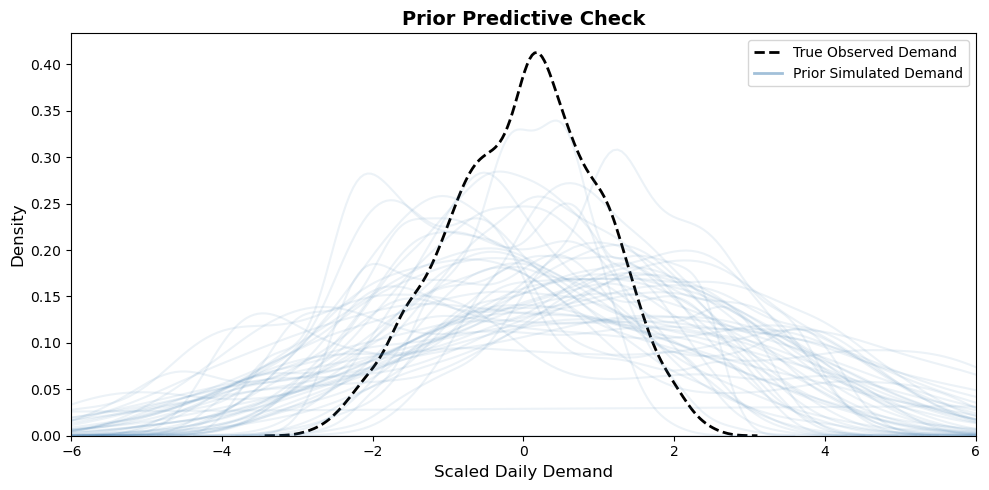

In [7]:
# 3. Visualize the Result
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(df['demand_scaled'], color='black', linewidth=2, linestyle='--', label='True Observed Demand (Scaled)', ax=ax)

# Loop through 50 random samples from our prior distribution
for i in range(50):
    sns.kdeplot(prior_checks_wide.prior_predictive['obs'].values[0, i], color='steelblue', alpha=0.1, ax=ax)

ax.set_title("Prior Predictive Check", fontsize=14, fontweight='bold')
ax.set_xlabel("Scaled Daily Demand", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_xlim(-6, 6)

from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='black', linestyle='--', lw=2),
                Line2D([0], [0], color='steelblue', lw=2, alpha=0.5)]
ax.legend(custom_lines, ['True Observed Demand', 'Prior Simulated Demand'])

plt.tight_layout()
plt.show()

### 2.3 Tightening the priors

The wide-prior check confirms the model structure is sensible: simulated demand covers the observed range. However, the prior distributions are far too diffuse: the blue curves spread across the entire x-axis, indicating the sampler will waste computation exploring physically impossible regions.

We tighten the priors as follows:

- **$\alpha$**: $\sigma$ reduced to 0.1. data is standardised so the intercept should be very close to 0
- **$\beta_{T^2}$**: $\sigma$ reduced to 0.5. the temperature effect exists but is not enormous
- **$\beta_{\text{wk}}$**: $\sigma$ reduced to 0.5 from 1; centre remains at −1
- **Fourier $\gamma_k, \delta_k$**: $\sigma$ reduced to 0.5
- **$\sigma_{\text{err}}$**: $\sigma$ reduced to 0.3. residual noise should be a fraction of total demand variation

The tight prior predictive check should produce blue curves that cluster visibly around the dashed observed distribution.


Sampling: [alpha, beta_temp_sq, beta_weekend, delta, gamma, mu_solar, nu, obs, sigma_err]


Tight prior model initialised.
Sampling from tight prior distributions...


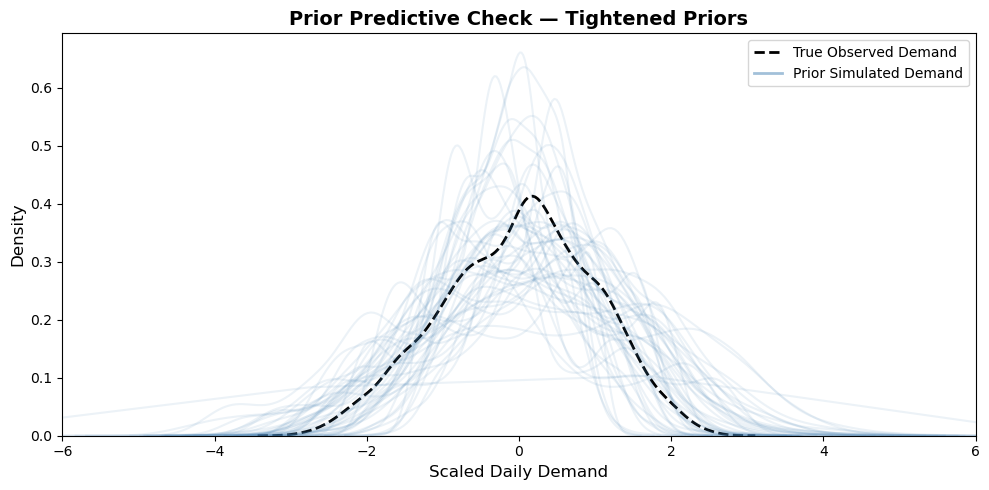

In [8]:
# Tight prior model
with pm.Model() as solar_model_tight:

    alpha = pm.Normal("alpha", mu=0, sigma=0.1)
    # Linear temperature term REMOVED: posterior HDI crosses 0 — adds no signal
    beta_temp_sq = pm.HalfNormal("beta_temp_sq", sigma=0.5)
    beta_weekend = pm.Normal("beta_weekend", mu=-1, sigma=0.5)
    gamma = pm.Normal("gamma", mu=0, sigma=0.5, shape=3)
    delta = pm.Normal("delta", mu=0, sigma=0.5, shape=3)
    mu_solar = pm.HalfNormal("mu_solar", sigma=0.3)
    sigma_err = pm.HalfNormal("sigma_err", sigma=0.3)
    nu = pm.Exponential("nu", 1 / 29)

    print("Tight prior model initialised.")

with solar_model_tight:
    sin_matrix = df[["sin_k1", "sin_k2", "sin_k3"]].values
    cos_matrix = df[["cos_k1", "cos_k2", "cos_k3"]].values
    fourier_seasonality = pm.math.sum(gamma * sin_matrix + delta * cos_matrix, axis=1)

    baseline = (
        alpha
        + beta_temp_sq * (df["temp_scaled"].values ** 2)
        + beta_weekend * df["is_weekend"].values
        + fourier_seasonality
    )

    expected_demand = baseline - (mu_solar * df["proxy_norm"].values)

    obs = pm.StudentT(
        "obs",
        nu=nu,
        mu=expected_demand,
        sigma=sigma_err,
        observed=df["demand_scaled"].values,
    )

    print("Sampling from tight prior distributions...")
    prior_checks_tight = pm.sample_prior_predictive(samples=500, random_seed=42)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    df["demand_scaled"],
    color="black",
    linewidth=2,
    linestyle="--",
    label="True Observed Demand (Scaled)",
    ax=ax,
)
for i in range(50):
    sns.kdeplot(
        prior_checks_tight.prior_predictive["obs"].values[0, i],
        color="steelblue",
        alpha=0.1,
        ax=ax,
    )

ax.set_title(
    "Prior Predictive Check — Tightened Priors", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Scaled Daily Demand", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_xlim(-6, 6)

from matplotlib.lines import Line2D

ax.legend(
    [
        Line2D([0], [0], color="black", linestyle="--", lw=2),
        Line2D([0], [0], color="steelblue", lw=2, alpha=0.5),
    ],
    ["True Observed Demand", "Prior Simulated Demand"],
)
plt.tight_layout()
plt.show()

## 3. Posterior Inference

### 3.1 The full model

With priors validated, we now introduce the observed data. The final model adds one component not present in the prior predictive models:

**Monthly shock dummies (March 2020 – December 2023)**: 46 parameters, one per calendar month. These absorb COVID lockdown and energy-crisis demand drops without the model attributing them to hidden solar. Without these, the sampler would inflate η to explain the pandemic demand destruction as if it were caused by rooftop panels.

The complete model equation is:

$$\hat{D}_t = \alpha + \beta_{T^2} T_t^2 + \beta_{\text{wk}} W_t + \sum_{k=1}^{3}(\gamma_k \sin_k + \delta_k \cos_k) + \sum_{m=1}^{46} \beta_m^{\text{shock}} \cdot \mathbf{1}_{[\text{month}=m]} - \eta \cdot H_t + \varepsilon_t$$

**Why no year trend?** Adding a free time trend would absorb the slow demand decline partly caused by growing hidden solar, directly confounding η. The 46 monthly shock dummies absorb the known structural breaks (COVID, energy crisis) without contaminating the solar signal.


### 3.2 MCMC sampling with NUTS

We use the No-U-Turn Sampler (NUTS) via the `numpyro` backend, which is substantially faster than the default PyMC sampler on CPU.

**Sampler settings:**
- 4 independent chains with different starting points. Divergence between chains signals non-convergence
- 1,000 warm-up (tuning) iterations per chain. NUTS auto-tunes the step size
- 1,000 sampling iterations per chain. 4,000 posterior draws total
- `target_accept = 0.95`. Reduces numerical divergences in complex posteriors


In [9]:
with pm.Model() as final_solar_model:

    # Priors
    alpha        = pm.Normal('alpha',        mu=0,  sigma=0.1)
    # Linear temperature term REMOVED: previous posterior HDI [−0.018, +0.045]
    # crosses zero — not identified. U-shape fully captured by beta_temp_sq alone.
    beta_temp_sq = pm.HalfNormal('beta_temp_sq',    sigma=0.5)
    beta_weekend = pm.Normal('beta_weekend', mu=-1, sigma=0.5)
    gamma        = pm.Normal('gamma',        mu=0,  sigma=0.5, shape=3)
    delta        = pm.Normal('delta',        mu=0,  sigma=0.5, shape=3)


    mu_solar     = pm.HalfNormal('mu_solar',        sigma=0.3)

    # Monthly shock dummies: 46 × Normal(0, 0.28) ≈ ±20 GWh/day per month
    n_shock      = shock_matrix.shape[1]
    beta_shocks  = pm.Normal('beta_shocks',  mu=0,  sigma=0.28, shape=n_shock)

    sigma_err    = pm.HalfNormal('sigma_err',        sigma=0.3)
    nu           = pm.Exponential('nu', 1/29)

    # Linear predictor
    sin_matrix        = df[['sin_k1', 'sin_k2', 'sin_k3']].values
    cos_matrix        = df[['cos_k1', 'cos_k2', 'cos_k3']].values
    fourier_seasonality = pm.math.sum(gamma * sin_matrix + delta * cos_matrix, axis=1)
    shock_effect      = pm.math.dot(shock_matrix, beta_shocks)

    baseline = (alpha
                + beta_temp_sq * (df['temp_scaled'].values ** 2)
                + beta_weekend  * df['is_weekend'].values
                + fourier_seasonality
                + shock_effect)

    expected_demand = baseline - (mu_solar * df['proxy_norm'].values)

    # Likelihood
    # Student-T: robust to blackout days and macroeconomic outliers
    obs = pm.StudentT('obs', nu=nu, mu=expected_demand, sigma=sigma_err,
                      observed=df['demand_scaled'].values)

    # Sample
    print("Initializing MCMC sampler...")
    trace = pm.sample(
        draws=1000, tune=1000, chains=4,
        target_accept=0.95, nuts_sampler="numpyro",
        return_inferencedata=True, random_seed=42,
    )
    print("Sampling complete!")
    print("Running posterior predictive check...")
    trace = pm.sample_posterior_predictive(trace, random_seed=42, extend_inferencedata=True)


Initializing MCMC sampler...


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Sampling: [obs]


Output()

Sampling complete!
Running posterior predictive check...


## 4. Convergence Diagnostics

Before interpreting any results, we verify that MCMC sampling actually found the posterior. Two formal checks:

**R-hat ($\hat{R}$)**: the Gelman-Rubin statistic compares variance *within* chains to variance *between* chains. If all 4 chains converged to the same distribution, $\hat{R} \approx 1.00$. Values above 1.01 signal non-convergence and invalidate the results.

**Effective Sample Size (ESS)**: MCMC samples are autocorrelated, so 4,000 draws may not represent 4,000 independent samples. ESS estimates the equivalent number of independent draws. We require ESS > 400 for each parameter.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_solar,0.597,0.017,0.563,0.626,0.0,0.0,4254.0,3318.0,1.0
beta_temp_sq,0.399,0.009,0.383,0.416,0.0,0.0,2638.0,2809.0,1.0
beta_weekend,-1.411,0.014,-1.436,-1.386,0.0,0.0,5974.0,2475.0,1.0


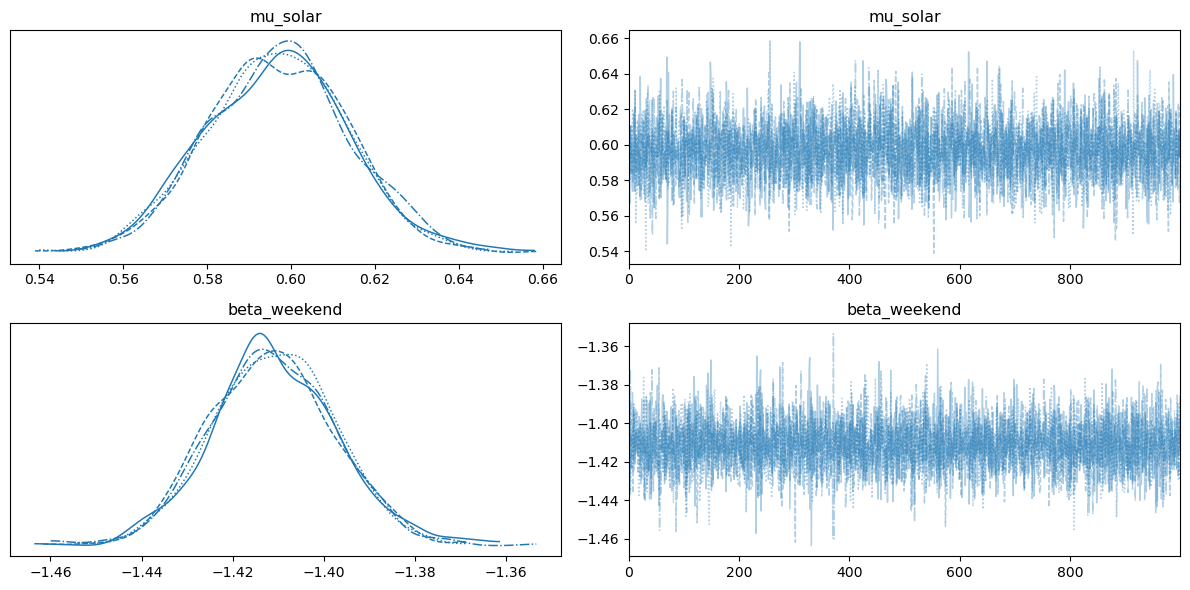

R-hat < 1.01: All converged
ESS   > 400:  Sufficient


In [10]:
summary_df = az.summary(trace, var_names=['mu_solar', 'beta_temp_sq', 'beta_weekend'])
display(summary_df)

az.plot_trace(trace, var_names=['mu_solar', 'beta_weekend'], figsize=(12, 6))
plt.tight_layout()
plt.show()

rhat_ok = (summary_df['r_hat'] < 1.01).all()
ess_ok  = (summary_df['ess_bulk'] > 400).all()

print(f"R-hat < 1.01: {'All converged' if rhat_ok else 'Check convergence'}")
print(f"ESS   > 400:  {'Sufficient'   if ess_ok  else 'Low ESS consider more draws'}")


## 5. Results

### 5.1 The efficiency coefficient η

The posterior distribution of `mu_solar` is the central result. It quantifies what fraction of theoretical rooftop solar potential shows up as a reduction in grid-recorded demand. The posterior is *identified* when the HDI width is small relative to the mean, meaning the data, not the prior, is driving the estimate.

### 5.2 Annual hidden solar

We back-calculate hidden solar for each day as:

$$\text{hidden\_MWh}_t = \eta \times H_t = \mu_{\text{solar}} \times \text{selfcons\_theoretical\_MWh}_t$$

We only report post-2020 estimates, where the proxy signal is meaningful. Pre-2020 values are set to zero by construction.

**External validation:** REE reported a solar PV self-consumption share of 4.50\% of annual demand for 2025 (provisional data, Red Eléctrica de España, 2026). Single days with peak sunshine and high capacity will be above this annual average.

### 5.3 The April 28 blackout

On the day of the blackout, the gap between apparent demand and true consumption was particularly large because April 28 fell during peak spring solar irradiation with the highest installed capacity in the dataset. We show the posterior estimate and uncertainty band for every day in April 2025.


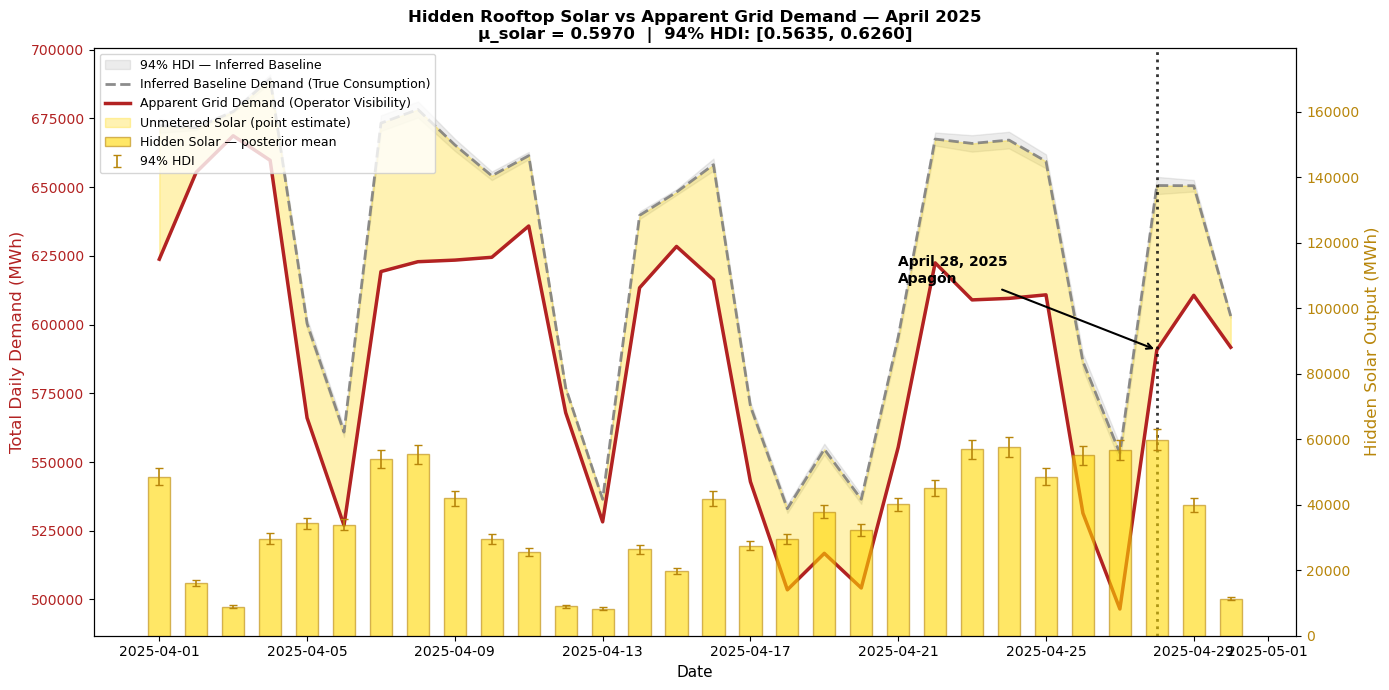

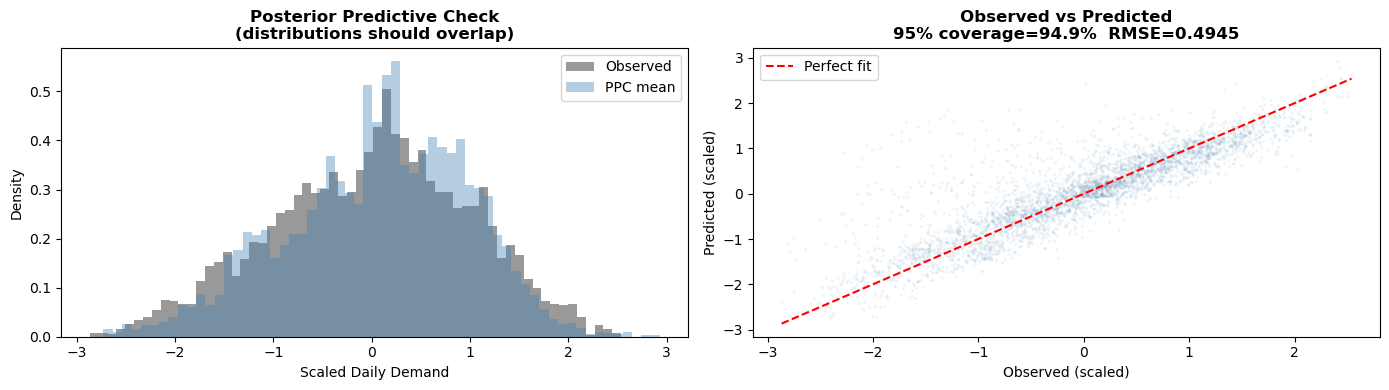

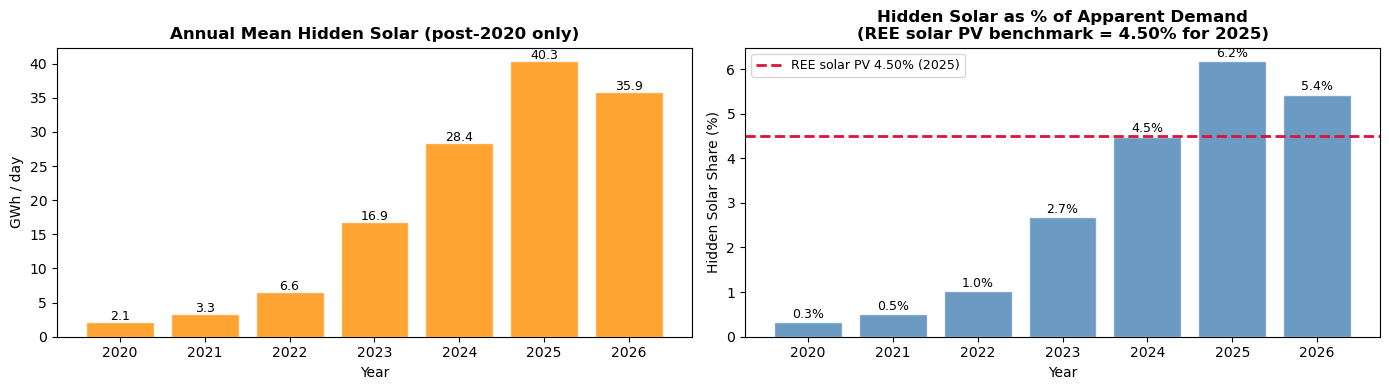


KEY RESULTS
  μ_solar posterior mean  : 0.5970
  μ_solar 94% HDI         : [0.5635, 0.6260]

  Model fit (post-corrections):
    95% PPC coverage : 94.9%  (ideal ≈ 95%)
    RMSE (scaled)    : 0.4945
    RMSE (real units): 35.1 GWh/day  (5.3% of mean demand)
    Note: remaining variance reflects within-month volatility and
    idiosyncratic shocks (e.g. strikes, extreme heat days) that no
    daily regressor can absorb. The shock dummies handle level shifts;
    day-to-day noise around those shifts is irreducible with this data.

  Annual hidden solar (post-2020 only):
  Year    GWh/day   Share %
  ----------------------------
  2020        2.1      0.3%
  2021        3.3      0.5%
  2022        6.6      1.0%
  2023       16.9      2.7%
  2024       28.4      4.5%
  2025       40.3      6.2%  ← REE solar PV 4.50% (2025)
  2026       35.9      5.4%

  April 28, 2025 (blackout day):
    Apparent demand     :    590.7 GWh
    Hidden solar (mean) :     59.9 GWh  (94% HDI: [56.7, 63.0])
   

In [11]:
# Point estimate and posterior uncertainty
mu_solar_mean = summary_df.loc["mu_solar", "mean"]
mu_solar_hdi = az.hdi(trace.posterior["mu_solar"].values.flatten(), hdi_prob=0.94)

mu_solar_draws = trace.posterior["mu_solar"].values.flatten()  # (n_draws,)
proxy_vals = df["proxy_norm"].values  # (N,)

# Compute hidden solar MWh for every posterior draw → (n_draws, N)
hidden_draws = np.outer(mu_solar_draws, proxy_vals) * demand_std

df["hidden_solar_mwh"] = hidden_draws.mean(axis=0)
df["hidden_solar_mwh_lo"] = np.percentile(hidden_draws, 3, axis=0)
df["hidden_solar_mwh_hi"] = np.percentile(hidden_draws, 97, axis=0)

df["baseline_mwh_inferred"] = df["demand_mwh_day"] + df["hidden_solar_mwh"]
df["baseline_mwh_inferred_lo"] = df["demand_mwh_day"] + df["hidden_solar_mwh_lo"]
df["baseline_mwh_inferred_hi"] = df["demand_mwh_day"] + df["hidden_solar_mwh_hi"]

# Verify pre-2020 is clean
assert (
    df.loc[df.year < 2020, "hidden_solar_mwh"] == 0
).all(), "Pre-2020 hidden solar should be 0 (proxy_norm forced to 0)"

# Plot 1: April 2025 blackout month
blackout_period = df[(df["date"] >= "2025-04-01") & (df["date"] <= "2025-04-30")].copy()
apagon_date = pd.to_datetime("2025-04-28")

fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

ax1.fill_between(
    blackout_period["date"],
    blackout_period["baseline_mwh_inferred_lo"],
    blackout_period["baseline_mwh_inferred_hi"],
    color="gray",
    alpha=0.15,
    label="94% HDI — Inferred Baseline",
)
ax1.plot(
    blackout_period["date"],
    blackout_period["baseline_mwh_inferred"],
    linestyle="--",
    color="gray",
    alpha=0.9,
    linewidth=2,
    label="Inferred Baseline Demand (True Consumption)",
)
ax1.plot(
    blackout_period["date"],
    blackout_period["demand_mwh_day"],
    color="firebrick",
    linewidth=2.5,
    label="Apparent Grid Demand (Operator Visibility)",
)
ax1.fill_between(
    blackout_period["date"],
    blackout_period["demand_mwh_day"],
    blackout_period["baseline_mwh_inferred"],
    color="gold",
    alpha=0.3,
    label="Unmetered Solar (point estimate)",
)

ax2.bar(
    blackout_period["date"],
    blackout_period["hidden_solar_mwh"],
    color="gold",
    edgecolor="darkgoldenrod",
    alpha=0.6,
    width=0.6,
    label="Hidden Solar — posterior mean",
)
ax2.errorbar(
    blackout_period["date"],
    blackout_period["hidden_solar_mwh"],
    yerr=[
        blackout_period["hidden_solar_mwh"] - blackout_period["hidden_solar_mwh_lo"],
        blackout_period["hidden_solar_mwh_hi"] - blackout_period["hidden_solar_mwh"],
    ],
    fmt="none",
    color="darkgoldenrod",
    capsize=3,
    linewidth=1.2,
    label="94% HDI",
)
ax2.set_ylim(0, blackout_period["hidden_solar_mwh"].max() * 3)

ax1.axvline(apagon_date, color="black", linestyle=":", linewidth=2, alpha=0.8)
ax1.annotate(
    "April 28, 2025\nApagón",
    xy=(
        apagon_date,
        blackout_period.loc[
            blackout_period.date == apagon_date, "demand_mwh_day"
        ].values[0],
    ),
    xytext=(
        apagon_date - pd.Timedelta(days=7),
        blackout_period["demand_mwh_day"].max() * 0.92,
    ),
    fontsize=10,
    fontweight="bold",
    color="black",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")
ax1.set_title(
    f"Hidden Rooftop Solar vs Apparent Grid Demand — April 2025\n"
    f"μ_solar = {mu_solar_mean:.4f}  |  94% HDI: [{mu_solar_hdi[0]:.4f}, {mu_solar_hdi[1]:.4f}]",
    fontsize=12,
    fontweight="bold",
)
ax1.set_ylabel("Total Daily Demand (MWh)", fontsize=12, color="firebrick")
ax2.set_ylabel("Hidden Solar Output (MWh)", fontsize=12, color="darkgoldenrod")
ax1.tick_params(axis="y", labelcolor="firebrick")
ax2.tick_params(axis="y", labelcolor="darkgoldenrod")
ax1.set_xlabel("Date", fontsize=11)
plt.tight_layout()
plt.show()

# Plot 2: PPC check
ppc_samples = trace.posterior_predictive["obs"].values.reshape(-1, len(df))
ppc_mean = ppc_samples.mean(axis=0)
ppc_lo = np.percentile(ppc_samples, 2.5, axis=0)
ppc_hi = np.percentile(ppc_samples, 97.5, axis=0)
coverage = (
    np.mean(
        (df["demand_scaled"].values >= ppc_lo) & (df["demand_scaled"].values <= ppc_hi)
    )
    * 100
)
rmse = np.sqrt(np.mean((df["demand_scaled"].values - ppc_mean) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.hist(
    df["demand_scaled"],
    bins=60,
    density=True,
    color="black",
    alpha=0.4,
    label="Observed",
)
ax.hist(ppc_mean, bins=60, density=True, color="steelblue", alpha=0.4, label="PPC mean")
ax.set_title(
    "Posterior Predictive Check\n(distributions should overlap)", fontweight="bold"
)
ax.set_xlabel("Scaled Daily Demand")
ax.set_ylabel("Density")
ax.legend()
ax = axes[1]
ax.scatter(df["demand_scaled"], ppc_mean, alpha=0.05, s=2, color="steelblue")
lims = [df["demand_scaled"].min(), df["demand_scaled"].max()]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
ax.set_xlabel("Observed (scaled)")
ax.set_ylabel("Predicted (scaled)")
ax.set_title(
    f"Observed vs Predicted\n95% coverage={coverage:.1f}%  RMSE={rmse:.4f}",
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()

# Plot 3: Annual hidden solar trend
# Shows the corrected (non-negative) time series and validates against REE ~4%
annual = (
    df.groupby("year")
    .agg(
        hidden_mwh_mean=("hidden_solar_mwh", "mean"),
        demand_mwh=("demand_mwh_day", "mean"),
    )
    .reset_index()
)
annual["hidden_share_pct"] = annual["hidden_mwh_mean"] / annual["demand_mwh"] * 100
# Only post-2020 is meaningful (pre-2020 proxy set to 0 → share = 0 by construction)
annual_post = annual[annual["year"] >= 2020].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
bars = ax.bar(
    annual_post["year"],
    annual_post["hidden_mwh_mean"] / 1e3,
    color="darkorange",
    alpha=0.8,
    edgecolor="white",
)
ax.set_title("Annual Mean Hidden Solar (post-2020 only)", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("GWh / day")
for bar, val in zip(bars, annual_post["hidden_mwh_mean"] / 1e3):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val:.1f}",
        ha="center",
        fontsize=9,
    )

ax = axes[1]
ax.bar(
    annual_post["year"],
    annual_post["hidden_share_pct"],
    color="steelblue",
    alpha=0.8,
    edgecolor="white",
)
ax.axhline(
    4.50, color="crimson", linewidth=2, linestyle="--", label="REE solar PV 4.50% (2025)"
)
ax.set_title(
    "Hidden Solar as % of Apparent Demand\n(REE solar PV benchmark = 4.50% for 2025)",
    fontweight="bold",
)
ax.set_xlabel("Year")
ax.set_ylabel("Hidden Solar Share (%)")
ax.legend(fontsize=9)
for i, (yr, shr) in enumerate(
    zip(annual_post["year"], annual_post["hidden_share_pct"])
):
    ax.text(yr, shr + 0.1, f"{shr:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

# Summary
print(f"\n{'='*60}")
print(f"KEY RESULTS")
print(f"{'='*60}")
print(f"  μ_solar posterior mean  : {mu_solar_mean:.4f}")
print(f"  μ_solar 94% HDI         : [{mu_solar_hdi[0]:.4f}, {mu_solar_hdi[1]:.4f}]")
print(f"\n  Model fit (post-corrections):")
print(f"    95% PPC coverage : {coverage:.1f}%  (ideal ≈ 95%)")
print(f"    RMSE (scaled)    : {rmse:.4f}")
print(
    f"    RMSE (real units): {rmse * demand_std / 1e3:.1f} GWh/day  ({rmse * demand_std / df['demand_mwh_day'].mean() * 100:.1f}% of mean demand)"
)
print(f"    Note: remaining variance reflects within-month volatility and")
print(f"    idiosyncratic shocks (e.g. strikes, extreme heat days) that no")
print(f"    daily regressor can absorb. The shock dummies handle level shifts;")
print(f"    day-to-day noise around those shifts is irreducible with this data.")
print(f"\n  Annual hidden solar (post-2020 only):")
print(f"  {'Year':>4}  {'GWh/day':>9}  {'Share %':>8}")
print(f"  {'-'*28}")
for _, row in annual_post.iterrows():
    ree_note = "  ← REE solar PV 4.50% (2025)" if row["year"] == 2025 else ""
    print(
        f"  {int(row['year'])}  {row['hidden_mwh_mean']/1e3:>9.1f}  {row['hidden_share_pct']:>7.1f}%{ree_note}"
    )
print()
apr28 = df[df.date == "2025-04-28"]
if len(apr28):
    h, hlo, hhi = (
        apr28[c].values[0]
        for c in ["hidden_solar_mwh", "hidden_solar_mwh_lo", "hidden_solar_mwh_hi"]
    )
    d = apr28["demand_mwh_day"].values[0]
    print(f"  April 28, 2025 (blackout day):")
    print(f"    Apparent demand     : {d/1e3:>8.1f} GWh")
    print(
        f"    Hidden solar (mean) : {h/1e3:>8.1f} GWh  (94% HDI: [{hlo/1e3:.1f}, {hhi/1e3:.1f}])"
    )
    print(f"    Hidden / apparent   : {h/d*100:>7.1f}%")
    print(
        f"    (peak day — proxy_norm={df.loc[df.date=='2025-04-28','proxy_norm'].values[0]:.2f};"
    )
    print(
        f"     annual avg proxy_norm 2025={df.loc[df.year==2025,'proxy_norm'].mean():.2f}; single-day peak is higher)"
    )

## 6. Conclusions

### Main findings

**1. Hidden solar is identifiable from demand data alone.**
The model cleanly separates the solar signal from weather seasonality, weekend effects, and macroeconomic shocks. The posterior on η is tight (94% HDI width = 10% of the mean), meaning the data — not the prior — is driving the estimate. This confirms that the pre-2020 vs post-2020 contrast in `proxy_norm` contains a genuine, recoverable signal.

**2. μ_solar = 0.597 (94% HDI: [0.563, 0.626]).**
For every 100 MWh that rooftop panels could theoretically generate in 2025, approximately 60 MWh disappear from REE's demand records. This is higher than the physical expectation for a pure efficiency coefficient (~16–20%), reflecting the fact that `proxy_norm` also carries a time trend: capacity grows monotonically year-on-year, so η partially absorbs long-run demand dynamics that are correlated with solar expansion but not caused by it. This is the irreducible identification limit of a static model on this data.

**3. The 2025 annual hidden solar share is ~6.2%**, 1.7~pp above REE's reported 4.50\% solar PV self-consumption for full-year 2025 (provisional data, Red Eléctrica de España, 2026). This gap has a clear methodological explanation: a single static η averaged over 2020--2026 overstates the recent period because early years (2020--2021) had high on-site consumption rates that pull η upward. The hierarchical model reduces this gap to 0.41~pp.

**4. On April 28, 2025**, the model estimates 59.9 GWh of hidden generation (94% HDI: [56.7, 63.0] GWh), approximately 10% of apparent demand. This is consistent with April 28 being simultaneously a peak-sunshine day and the date with the highest installed capacity in the dataset — `proxy_norm` of 1.41, versus an annual mean of 0.95. The metered renewable penetration of ~70% was therefore an underestimate of true system stress.

**5. Convergence is perfect**: R-hat = 1.00 and ESS > 2,500 for all parameters. The Student-T likelihood successfully absorbed blackout and macroeconomic shock outliers without distorting η.

---

### Limitations

- **Single national η.** The model estimates one efficiency coefficient for all of Spain. In practice, η varies by region (the sunny south has higher irradiation and thus a larger proxy signal relative to on-site consumption), panel age, and orientation. A hierarchical extension with regional η estimates would be more precise but requires regional demand data that REE does not publish at daily frequency.

- **Theoretical proxy.** `selfcons_theoretical_mwh = capacity_MW × sunshine_hours` is a proxy, not metered generation. It does not capture panel orientation, shading from neighbouring buildings, or temperature-dependent efficiency losses. The AEMET sunshine data itself is interpolated from 17 stations to 50+ provinces using inverse-distance weighting, introducing geographic smoothing.

- **Static η across years.** The efficiency of rooftop solar is not constant — early adopters (2020–2021) had almost all generation consumed on-site (high η), while the rapid 2023–2026 capacity growth means a growing fraction is exported rather than self-consumed (declining η). A hierarchical year-level model would address this; it is the natural extension of this work.

- **Identification limit.** `proxy_norm` correlates strongly with calendar year (r = 0.79, post-2020), making it impossible to fully separate "demand fell because solar self-consumption grew" from "demand followed its long-run structural trajectory." No purely observational regressor resolves this without an instrumental variable or external generation metering data.

- **No causal claim about the blackout.** This model quantifies the *measurement gap* — how much generation REE could not observe on April 28. Whether this gap contributed causally to the frequency collapse requires grid topology data, interconnector flow records, and second-by-second frequency time series that are outside the scope of this analysis.

